## Ridge(L2), Lasso(L1) and ElasticNet Regression

In [255]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [256]:
df=pd.read_csv('../data/forest_dataset_cleaned.csv')
df.head(5)

,day,month,year,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes,region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [257]:
df.drop(columns=['day','month','year'], inplace=True)
df.head(5)

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [258]:
df['classes'].value_counts()

classes
fire        137
not fire    106
Name: count, dtype: int64

In [259]:
#Encoding of the classes
classes_mapping={'not fire':0, 'fire':1}
df['classes']=df['classes'].map(classes_mapping)

In [260]:
#Split the data into features and target variable
X=df.drop(columns=['fwi'])
y=df['fwi']


In [261]:
X.head(5)

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [262]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training set size: {X_train.shape[0]} samples')
print(f'Test set size: {X_test.shape[0]} samples')

Training set size: 194 samples
Test set size: 49 samples


Text(0.5, 1.0, 'Correlation  of Training Data')

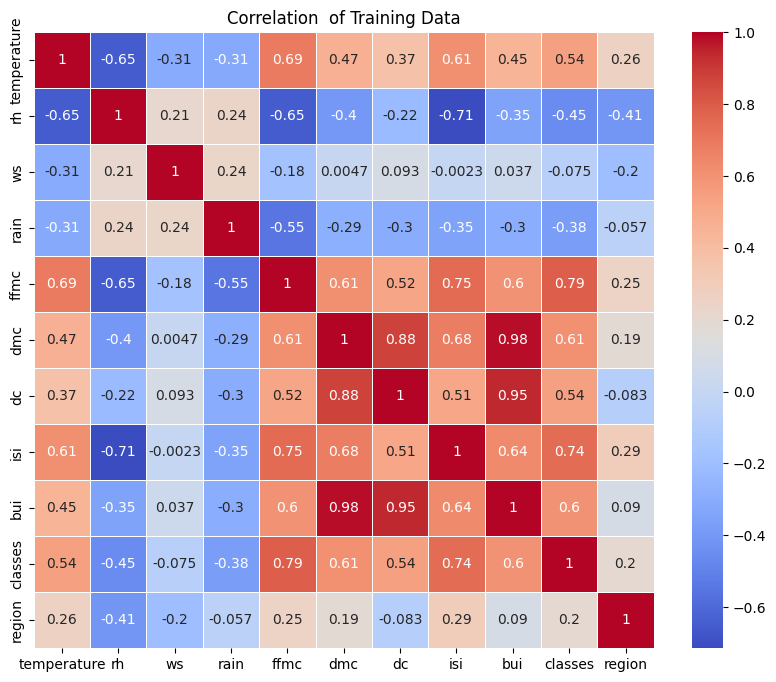

In [263]:
#Correlation heatmap of training data
plt.figure(figsize=(10,8))
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation  of Training Data')

In [264]:
def check_correlation(data, threshold=0.95):
    corr_matrix = data.corr()
    result = set()
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                result.add(colname)
    
    return result
  
correlated_features = check_correlation(X_train, threshold=0.85)
correlated_features

{'bui', 'dc'}

In [265]:
#Drop highly correlated features
X_train.drop(columns=correlated_features, inplace=True)
X_test.drop(columns=correlated_features, inplace=True)

In [266]:
#Standardization of features
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Text(0.5, 1.0, 'Boxplot of Training Features after Scaling')

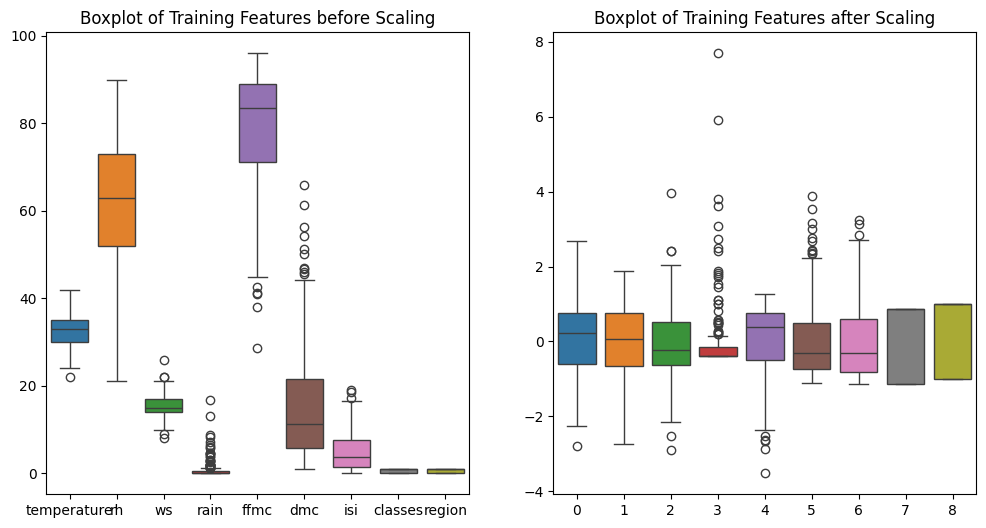

In [267]:
plt.subplots(1,2,figsize=(12,6))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title('Boxplot of Training Features before Scaling')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title('Boxplot of Training Features after Scaling')

### Linear Regression

In [268]:
linear_reg=LinearRegression()
linear_reg.fit(X_train_scaled, y_train)
y_pred=linear_reg.predict(X_test_scaled)
mae=mean_absolute_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R2 Score: {r2:.2f}')

Mean Absolute Error: 0.50
R2 Score: 0.98


Text(0.5, 1.0, 'Actual vs Predicted Values')

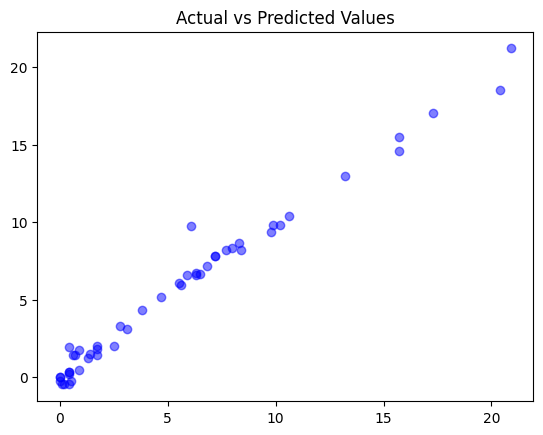

In [269]:
#Actual vs Predicted values with color coding
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.title('Actual vs Predicted Values')

### Lasso Regression

Mean Absolute Error: 1.01
R2 Score: 0.94


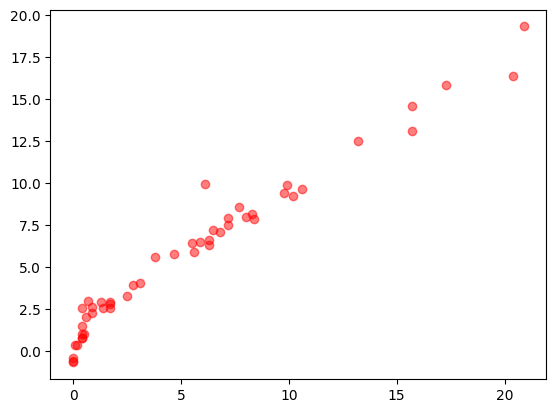

In [270]:
lasso=Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred=lasso.predict(X_test_scaled)
mae_lasso=mean_absolute_error(y_test, y_pred)
r2_lasso=r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae_lasso:.2f}')
print(f'R2 Score: {r2_lasso:.2f}')
plt.scatter(y_test, y_pred, color='red', alpha=0.5)


### Cross Validation Lasso

Optimal alpha for LassoCV: 0.0471
Mean Absolute Error for LassoCV: 0.56
R2 Score for LassoCV: 0.98


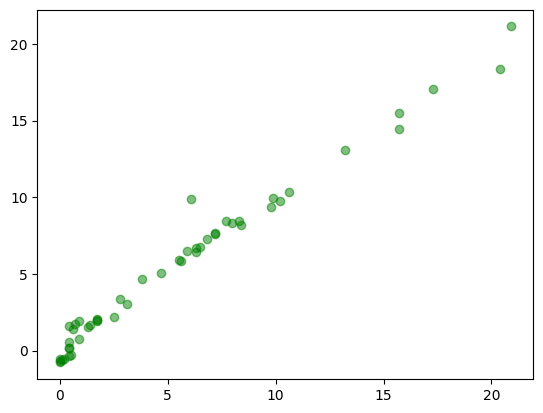

In [271]:
lasso_cv=LassoCV(cv=5)
lasso_cv.fit(X_train_scaled, y_train)
alpha_lasso_cv=lasso_cv.alpha_
print(f'Optimal alpha for LassoCV: {alpha_lasso_cv:.4f}')
y_pred_lasso_cv=lasso_cv.predict(X_test_scaled)
mae_lasso_cv=mean_absolute_error(y_test, y_pred_lasso_cv)
r2_lasso_cv=r2_score(y_test, y_pred_lasso_cv)
print(f'Mean Absolute Error for LassoCV: {mae_lasso_cv:.2f}')
print(f'R2 Score for LassoCV: {r2_lasso_cv:.2f}')
plt.scatter(y_test, y_pred_lasso_cv, color='green', alpha=0.5)


### Ridge Regression 

Mean Absolute Error: 0.52
R2 Score: 0.98


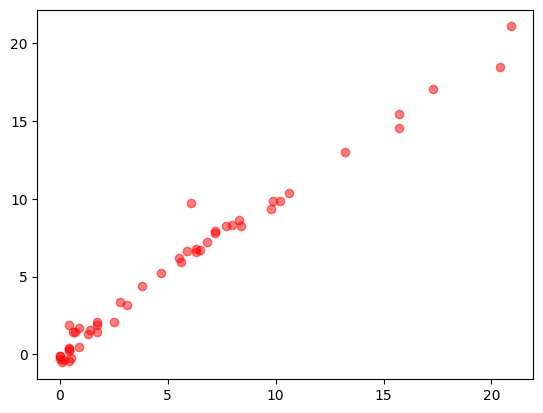

In [272]:
ridge=Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred=ridge.predict(X_test_scaled)
mae_ridge=mean_absolute_error(y_test, y_pred)
r2_ridge=r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae_ridge:.2f}')
print(f'R2 Score: {r2_ridge :.2f}')
plt.scatter(y_test, y_pred, color='red', alpha=0.5)


### Ridge Cross Validation

Optimal alpha for RidgeCV: 10.0000
Mean Absolute Error for LassoCV: 0.56
R2 Score for LassoCV: 0.98


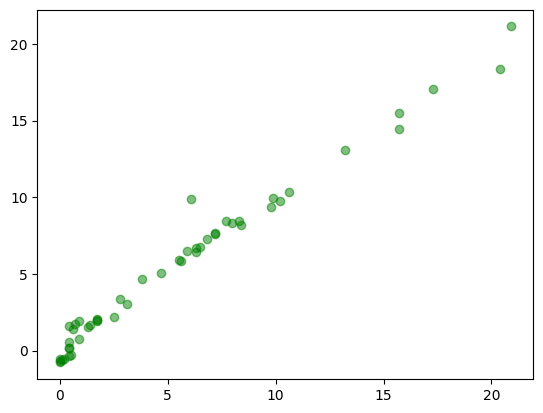

In [273]:
ridge_cv=RidgeCV(cv=5)
ridge_cv.fit(X_train_scaled, y_train)
alpha_ridge_cv=ridge_cv.alpha_
print(f'Optimal alpha for RidgeCV: {alpha_ridge_cv:.4f}')
y_pred_ridge_cv=ridge_cv.predict(X_test_scaled)
mae_ridge_cv=mean_absolute_error(y_test, y_pred_ridge_cv)
r2_ridge_cv=r2_score(y_test, y_pred_ridge_cv)
print(f'Mean Absolute Error for LassoCV: {mae_lasso_cv:.2f}')
print(f'R2 Score for LassoCV: {r2_lasso_cv:.2f}')
plt.scatter(y_test, y_pred_lasso_cv, color='green', alpha=0.5)


### ElasticNet Regression

Mean Absolute Error: 1.68
R2 Score: 0.87


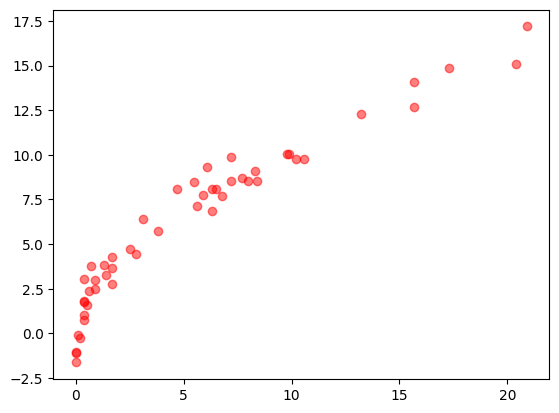

In [274]:
elastic=ElasticNet()
elastic.fit(X_train_scaled, y_train)
y_pred=elastic.predict(X_test_scaled)
mae_cross=mean_absolute_error(y_test, y_pred)
r2_cross=r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae_cross:.2f}')
print(f'R2 Score: {r2_cross :.2f}')
plt.scatter(y_test, y_pred, color='red', alpha=0.5)


### ElasticNet Cross Validation

Optimal alpha for ElasticNetCV: 0.0288
Mean Absolute Error for ElasticNetCV: 0.57
R2 Score for ElasticNetCV: 0.98


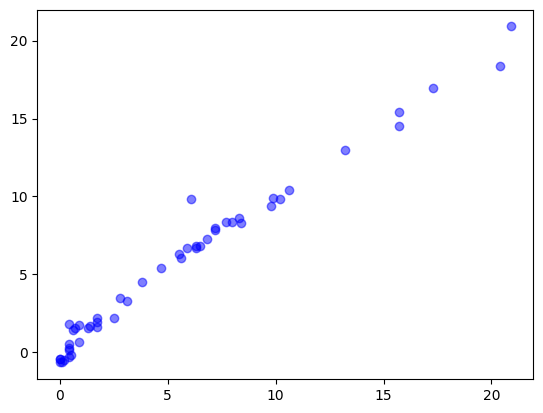

In [275]:
elastic_cv=ElasticNetCV(cv=5)
elastic_cv.fit(X_train_scaled, y_train)
alpha_elastic_cv=elastic_cv.alpha_
print(f'Optimal alpha for ElasticNetCV: {alpha_elastic_cv:.4f}')
y_pred_elastic_cv=elastic_cv.predict(X_test_scaled)
mae_elastic_cv=mean_absolute_error(y_test, y_pred_elastic_cv)
r2_elastic_cv=r2_score(y_test, y_pred_elastic_cv)
print(f'Mean Absolute Error for ElasticNetCV: {mae_elastic_cv:.2f}')
print(f'R2 Score for ElasticNetCV: {r2_elastic_cv:.2f}')
plt.scatter(y_test, y_pred_elastic_cv, color='blue', alpha=0.5)


Text(0, 0.5, 'Mean Absolute Error')

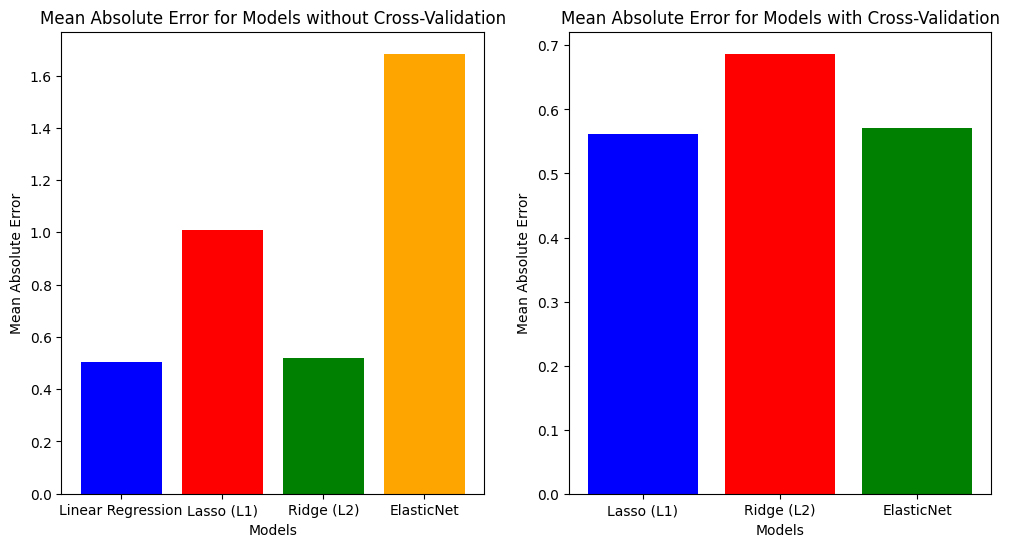

In [283]:
# Plot the errors for each model with and without the cross-validation
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.bar(['Linear Regression', 'Lasso (L1)', 'Ridge (L2)', 'ElasticNet'], [mae, mae_lasso, mae_ridge, mae_cross], color=['blue', 'red', 'green', 'orange'])
plt.title('Mean Absolute Error for Models without Cross-Validation')
plt.xlabel('Models')
plt.ylabel('Mean Absolute Error')
plt.subplot(1,2,2)
plt.bar(['Lasso (L1)', 'Ridge (L2)', 'ElasticNet'], [mae_lasso_cv, mae_ridge_cv, mae_elastic_cv], color=['blue', 'red', 'green', 'orange'])
plt.title('Mean Absolute Error for Models with Cross-Validation')
plt.xlabel('Models')
plt.ylabel('Mean Absolute Error')